In [67]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

SALES_DIR = BASE_DIR / "processed_sales"
MONTHLY_DIR = BASE_DIR / "monthly_forecast"
Q4_2025_DIR = BASE_DIR / "final_q4_2025_forecast"
Q2_Q3_2022_DIR = BASE_DIR / "q2_q3_2022_forecast"

FEATURE_OUT_DIR = BASE_DIR / "feature_contribution"
FEATURE_OUT_DIR.mkdir(parents=True, exist_ok=True)

In [68]:
metrics_files = [
    {
        "path": SALES_DIR / "yearly_cv_model_metrics.csv",
        "experiment": "yearly_cv_sales_all_years",
        "default_target": "sales_index"
    },
    {
        "path": SALES_DIR / "arimax_model_metrics.csv",
        "experiment": "sales_last_4_quarters_validation",
        "default_target": "sales_index"
    },
    {
        "path": MONTHLY_DIR / "full_2025_sarima_metrics.csv",
        "experiment": "monthly_price_full_2025",
        "default_target": "price_index"
    },
    {
        "path": MONTHLY_DIR / "monthly_2025_cv_all_metrics.csv",
        "experiment": "monthly_price_2025_by_month",
        "default_target": "price_index"
    },
    {
        "path": Q4_2025_DIR / "price_q4_2025_all_metrics.csv",
        "experiment": "price_q4_2025",
        "default_target": "price_index"
    },
    {
        "path": Q4_2025_DIR / "sales_q4_2025_all_metrics.csv",
        "experiment": "sales_q4_2025",
        "default_target": "sales_index"
    },
    {
        "path": Q2_Q3_2022_DIR / "price_q2_q3_2022_all_metrics.csv",
        "experiment": "price_q2_q3_2022",
        "default_target": "price_index"
    },
    {
        "path": Q2_Q3_2022_DIR / "sales_q2_q3_2022_all_metrics.csv",
        "experiment": "sales_q2_q3_2022",
        "default_target": "sales_index"
    },
]

loaded_metrics = []

for item in metrics_files:
    path = item["path"]
    
    if not path.exists():
        print("Файл не найден, пропускаю:", path)
        continue
    
    df = pd.read_csv(path)
    df["experiment"] = item["experiment"]
    
    if "target" not in df.columns:
        df["target"] = item["default_target"]
    else:
        df["target"] = df["target"].fillna(item["default_target"])
    
    loaded_metrics.append(df)
    print("Загружен:", path, "| строк:", len(df))

if not loaded_metrics:
    raise ValueError("Не найдено ни одного файла с метриками")

all_metrics = pd.concat(loaded_metrics, ignore_index=True)

print("Итого строк метрик:", len(all_metrics))
display(all_metrics.head())

Файл не найден, пропускаю: /content/gdrive/MyDrive/rostat/processed_sales/yearly_cv_model_metrics.csv
Загружен: /content/gdrive/MyDrive/rostat/processed_sales/arimax_model_metrics.csv | строк: 40
Загружен: /content/gdrive/MyDrive/rostat/monthly_forecast/full_2025_sarima_metrics.csv | строк: 81
Загружен: /content/gdrive/MyDrive/rostat/monthly_forecast/monthly_2025_cv_all_metrics.csv | строк: 531
Загружен: /content/gdrive/MyDrive/rostat/final_q4_2025_forecast/price_q4_2025_all_metrics.csv | строк: 63
Загружен: /content/gdrive/MyDrive/rostat/final_q4_2025_forecast/sales_q4_2025_all_metrics.csv | строк: 72
Загружен: /content/gdrive/MyDrive/rostat/q2_q3_2022_forecast/price_q2_q3_2022_all_metrics.csv | строк: 63
Загружен: /content/gdrive/MyDrive/rostat/q2_q3_2022_forecast/sales_q2_q3_2022_all_metrics.csv | строк: 56
Итого строк метрик: 906


,MAE,RMSE,MAPE,sMAPE,model,product_group_code,product_group_name,validation_size,train_start,train_end,...,target,model_type,component_test,train_months,valid_months,validation_month,train_n,valid_n,train_imputed_points,valid_imputed_points
0,29.260320,29.480827,13.804125,14.827866,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",4.0,2017-06-30,2024-12-31,...,sales_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.731581,7.094326,2.540169,2.587324,"SARIMA (0,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",4.0,2017-06-30,2024-12-31,...,sales_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6.989197,8.064113,3.150049,3.212834,"SARIMA (1,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",4.0,2017-06-30,2024-12-31,...,sales_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.073949,7.189163,2.732055,2.682266,"SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",4.0,2017-06-30,2024-12-31,...,sales_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.209050,4.690156,1.919019,1.897985,"SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",4.0,2017-06-30,2024-12-31,...,sales_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
required_cols = ["model", "product_group_code", "product_group_name", "MAE", "RMSE", "MAPE", "sMAPE"]

missing_required = [col for col in required_cols if col not in all_metrics.columns]

if missing_required:
    raise ValueError(f"В таблицах метрик не хватает колонок: {missing_required}")

if "model_type" not in all_metrics.columns:
    all_metrics["model_type"] = np.select(
        [
            all_metrics["model"].str.contains("Seasonal Naive", case=False, na=False),
            all_metrics["model"].str.contains("SARIMAX", case=False, na=False),
            all_metrics["model"].str.contains("SARIMA", case=False, na=False),
        ],
        [
            "Seasonal Naive",
            "SARIMAX",
            "SARIMA"
        ],
        default="Other"
    )

if "component_test" not in all_metrics.columns:
    all_metrics["component_test"] = all_metrics["model"]

# Универсальный validation_id, чтобы корректно сравнивать модели внутри одного и того же периода
def make_validation_id(row):
    if "validation_year" in row.index and pd.notna(row.get("validation_year")):
        return f"year_{int(row['validation_year'])}"
    
    if "validation_month" in row.index and pd.notna(row.get("validation_month")):
        return f"month_{pd.to_datetime(row['validation_month']).date()}"
    
    if "valid_start" in row.index and "valid_end" in row.index:
        if pd.notna(row.get("valid_start")) and pd.notna(row.get("valid_end")):
            return f"{pd.to_datetime(row['valid_start']).date()}_{pd.to_datetime(row['valid_end']).date()}"
    
    return "single_validation"

all_metrics["validation_id"] = all_metrics.apply(make_validation_id, axis=1)

all_metrics["MAPE"] = pd.to_numeric(all_metrics["MAPE"], errors="coerce")
all_metrics["sMAPE"] = pd.to_numeric(all_metrics["sMAPE"], errors="coerce")
all_metrics["MAE"] = pd.to_numeric(all_metrics["MAE"], errors="coerce")
all_metrics["RMSE"] = pd.to_numeric(all_metrics["RMSE"], errors="coerce")

all_metrics = all_metrics.dropna(subset=["MAPE"]).copy()

display(
    all_metrics[
        [
            "experiment",
            "target",
            "validation_id",
            "product_group_code",
            "product_group_name",
            "model_type",
            "model",
            "MAPE"
        ]
    ].head()
)

,experiment,target,validation_id,product_group_code,product_group_name,model_type,model,MAPE
0,sales_last_4_quarters_validation,sales_index,2025-03-31_2025-12-31,G01,"Хлеб, крупы, мука и макаронные изделия",NaN,Seasonal Naive,13.804125
1,sales_last_4_quarters_validation,sales_index,2025-03-31_2025-12-31,G01,"Хлеб, крупы, мука и макаронные изделия",NaN,"SARIMA (0,1,0)(0,1,1,4)",2.540169
2,sales_last_4_quarters_validation,sales_index,2025-03-31_2025-12-31,G01,"Хлеб, крупы, мука и макаронные изделия",NaN,"SARIMA (1,1,0)(0,1,1,4)",3.150049
3,sales_last_4_quarters_validation,sales_index,2025-03-31_2025-12-31,G01,"Хлеб, крупы, мука и макаронные изделия",NaN,"SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",2.732055
4,sales_last_4_quarters_validation,sales_index,2025-03-31_2025-12-31,G01,"Хлеб, крупы, мука и макаронные изделия",NaN,"SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",1.919019


In [70]:
match_cols = [
    "experiment",
    "target",
    "validation_id",
    "product_group_code"
]

baseline = (
    all_metrics[all_metrics["model_type"] == "Seasonal Naive"]
    [match_cols + ["MAPE", "sMAPE", "MAE", "RMSE"]]
    .rename(columns={
        "MAPE": "baseline_MAPE",
        "sMAPE": "baseline_sMAPE",
        "MAE": "baseline_MAE",
        "RMSE": "baseline_RMSE"
    })
)

model_rows = all_metrics[
    all_metrics["model_type"] != "Seasonal Naive"
].copy()

model_contribution = model_rows.merge(
    baseline,
    on=match_cols,
    how="inner"
)

model_contribution["mape_gain_pp"] = (
    model_contribution["baseline_MAPE"] - model_contribution["MAPE"]
)

model_contribution["smape_gain_pp"] = (
    model_contribution["baseline_sMAPE"] - model_contribution["sMAPE"]
)

model_contribution["mape_gain_percent"] = (
    model_contribution["mape_gain_pp"] /
    model_contribution["baseline_MAPE"]
) * 100

model_contribution["improved_vs_naive"] = model_contribution["mape_gain_pp"] > 0

display(
    model_contribution[
        [
            "experiment",
            "target",
            "validation_id",
            "product_group_name",
            "model_type",
            "model",
            "baseline_MAPE",
            "MAPE",
            "mape_gain_pp",
            "mape_gain_percent",
            "improved_vs_naive"
        ]
    ].head(20)
)

,experiment,target,validation_id,product_group_name,model_type,model,baseline_MAPE,MAPE,mape_gain_pp,mape_gain_percent,improved_vs_naive
0,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,"SARIMA no AR/MA, seasonal diff only",7.225230,4.526865,2.698365,37.346425,True
1,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,SARIMA + nonseasonal MA,7.225230,4.272128,2.953102,40.872088,True
2,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,SARIMA + nonseasonal AR,7.225230,2.745535,4.479695,62.000729,True
3,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,SARIMA + seasonal MA,7.225230,2.103168,5.122062,70.891336,True
4,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,SARIMA MA + seasonal MA,7.225230,1.915413,5.309817,73.489933,True
5,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,SARIMA AR + seasonal MA,7.225230,1.102783,6.122447,84.737056,True
6,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,SARIMA ARMA + seasonal MA,7.225230,1.127796,6.097434,84.390865,True
7,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия",SARIMA,SARIMA MA + seasonal AR,7.225230,9.190533,-1.965303,-27.200558,False
8,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,Молочная продукция и яйца,SARIMA,"SARIMA no AR/MA, seasonal diff only",9.152197,2.423777,6.728419,73.516989,True
9,monthly_price_full_2025,price_index,2025-01-31_2025-12-31,Молочная продукция и яйца,SARIMA,SARIMA + nonseasonal MA,9.152197,2.579526,6.572671,71.815224,True


In [71]:
model_contribution_summary = (
    model_contribution
    .groupby(["target", "model_type", "model", "component_test"], as_index=False)
    .agg(
        mean_baseline_MAPE=("baseline_MAPE", "mean"),
        mean_model_MAPE=("MAPE", "mean"),
        mean_mape_gain_pp=("mape_gain_pp", "mean"),
        mean_mape_gain_percent=("mape_gain_percent", "mean"),
        median_mape_gain_pp=("mape_gain_pp", "median"),
        improved_share=("improved_vs_naive", "mean"),
        n_runs=("MAPE", "size")
    )
    .sort_values("mean_mape_gain_pp", ascending=False)
)

model_contribution_summary["improved_share"] = (
    model_contribution_summary["improved_share"] * 100
)

display(model_contribution_summary.round(3))

,target,model_type,model,component_test,mean_baseline_MAPE,mean_model_MAPE,mean_mape_gain_pp,mean_mape_gain_percent,median_mape_gain_pp,improved_share,n_runs
3,price_index,SARIMA,"SARIMA (0,1,1)(0,1,1,12)",MA + сезонная MA,13.137,5.704,7.432,68.259,8.838,94.444,18
5,price_index,SARIMA,"SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,13.137,6.172,6.965,66.333,8.675,94.444,18
2,price_index,SARIMA,"SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,13.137,6.297,6.840,62.392,7.794,88.889,18
4,price_index,SARIMA,"SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,13.137,6.390,6.747,61.403,8.657,88.889,18
1,price_index,SARIMA,"SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,13.137,6.534,6.603,64.171,8.455,94.444,18
0,price_index,SARIMA,"SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,13.137,6.810,6.326,58.759,7.427,88.889,18
10,price_index,SARIMA,SARIMA ARMA + seasonal MA,ARMA + сезонная MA,9.554,4.101,5.453,45.828,7.061,88.889,9
12,price_index,SARIMA,SARIMA MA + seasonal MA,MA + сезонная MA,9.554,4.222,5.332,44.551,6.985,88.889,9
8,price_index,SARIMA,SARIMA + seasonal MA,добавлена сезонная MA-компонента,9.554,4.262,5.292,43.226,6.930,88.889,9
9,price_index,SARIMA,SARIMA AR + seasonal MA,AR + сезонная MA,9.554,4.354,5.200,43.072,6.862,88.889,9


In [72]:
def parse_order_key(model_name):
    text = str(model_name)
    
    match = re.search(
        r"\((\d+,\s*\d+,\s*\d+)\)\s*\((\d+,\s*\d+,\s*\d+,\s*\d+)\)",
        text
    )
    
    if not match:
        return None
    
    order = re.sub(r"\s+", "", match.group(1))
    seasonal_order = re.sub(r"\s+", "", match.group(2))
    
    return f"({order})({seasonal_order})"


def extract_exog_feature(model_name):
    text = str(model_name)
    
    if "price_index_lag1" in text:
        return "price_index_lag1"
    
    if "price_index_lag4" in text:
        return "price_index_lag4"
    
    if "price_index" in text:
        return "price_index_current"
    
    return None


all_metrics["order_key"] = all_metrics["model"].apply(parse_order_key)
all_metrics["exog_feature"] = all_metrics["model"].apply(extract_exog_feature)

sarima_base = (
    all_metrics[
        (all_metrics["model_type"] == "SARIMA") &
        (all_metrics["order_key"].notna())
    ]
    [match_cols + ["order_key", "MAPE", "sMAPE", "MAE", "RMSE"]]
    .rename(columns={
        "MAPE": "sarima_base_MAPE",
        "sMAPE": "sarima_base_sMAPE",
        "MAE": "sarima_base_MAE",
        "RMSE": "sarima_base_RMSE"
    })
)

sarimax_rows = all_metrics[
    (all_metrics["model_type"] == "SARIMAX") &
    (all_metrics["order_key"].notna())
].copy()

price_feature_contribution = sarimax_rows.merge(
    sarima_base,
    on=match_cols + ["order_key"],
    how="inner"
)

price_feature_contribution["feature_mape_gain_pp"] = (
    price_feature_contribution["sarima_base_MAPE"] -
    price_feature_contribution["MAPE"]
)

price_feature_contribution["feature_mape_gain_percent"] = (
    price_feature_contribution["feature_mape_gain_pp"] /
    price_feature_contribution["sarima_base_MAPE"]
) * 100

price_feature_contribution["feature_improved"] = (
    price_feature_contribution["feature_mape_gain_pp"] > 0
)

display(
    price_feature_contribution[
        [
            "experiment",
            "target",
            "validation_id",
            "product_group_name",
            "order_key",
            "exog_feature",
            "sarima_base_MAPE",
            "MAPE",
            "feature_mape_gain_pp",
            "feature_mape_gain_percent",
            "feature_improved"
        ]
    ].head(20)
)

,experiment,target,validation_id,product_group_name,order_key,exog_feature,sarima_base_MAPE,MAPE,feature_mape_gain_pp,feature_mape_gain_percent,feature_improved
0,sales_q4_2025,sales_index,2025-12-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","(0,1,0)(0,1,0,4)",price_index_lag1,0.069568,0.692116,-0.622548,-894.872615,False
1,sales_q4_2025,sales_index,2025-12-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","(0,1,0)(0,1,0,4)",price_index_lag4,0.069568,0.032912,0.036656,52.690947,True
2,sales_q4_2025,sales_index,2025-12-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","(1,1,0)(0,1,0,4)",price_index_lag1,0.231758,0.824950,-0.593193,-255.953963,False
3,sales_q4_2025,sales_index,2025-12-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","(1,1,0)(0,1,0,4)",price_index_lag4,0.231758,1.132861,-0.901104,-388.812945,False
4,sales_q4_2025,sales_index,2025-12-31_2025-12-31,Молочная продукция и яйца,"(0,1,0)(0,1,0,4)",price_index_lag1,3.140254,3.491074,-0.350820,-11.171693,False
5,sales_q4_2025,sales_index,2025-12-31_2025-12-31,Молочная продукция и яйца,"(0,1,0)(0,1,0,4)",price_index_lag4,3.140254,2.737121,0.403134,12.837613,True
6,sales_q4_2025,sales_index,2025-12-31_2025-12-31,Молочная продукция и яйца,"(1,1,0)(0,1,0,4)",price_index_lag1,4.650624,6.002442,-1.351818,-29.067456,False
7,sales_q4_2025,sales_index,2025-12-31_2025-12-31,Молочная продукция и яйца,"(1,1,0)(0,1,0,4)",price_index_lag4,4.650624,1.896927,2.753697,59.211351,True
8,sales_q4_2025,sales_index,2025-12-31_2025-12-31,"Мясо, птица, рыба и колбасные изделия","(0,1,0)(0,1,0,4)",price_index_lag1,1.177410,1.219558,-0.042148,-3.579736,False
9,sales_q4_2025,sales_index,2025-12-31_2025-12-31,"Мясо, птица, рыба и колбасные изделия","(0,1,0)(0,1,0,4)",price_index_lag4,1.177410,1.507581,-0.330172,-28.042195,False


In [73]:
price_feature_summary = (
    price_feature_contribution
    .groupby(["target", "exog_feature"], as_index=False)
    .agg(
        mean_sarima_base_MAPE=("sarima_base_MAPE", "mean"),
        mean_sarimax_MAPE=("MAPE", "mean"),
        mean_feature_gain_pp=("feature_mape_gain_pp", "mean"),
        mean_feature_gain_percent=("feature_mape_gain_percent", "mean"),
        median_feature_gain_pp=("feature_mape_gain_pp", "median"),
        improved_share=("feature_improved", "mean"),
        n_runs=("MAPE", "size")
    )
    .sort_values("mean_feature_gain_pp", ascending=False)
)

price_feature_summary["improved_share"] = (
    price_feature_summary["improved_share"] * 100
)

display(price_feature_summary.round(3))

,target,exog_feature,mean_sarima_base_MAPE,mean_sarimax_MAPE,mean_feature_gain_pp,mean_feature_gain_percent,median_feature_gain_pp,improved_share,n_runs
1,sales_index,price_index_lag4,7.581,7.559,0.022,-4.57,0.485,71.875,32
0,sales_index,price_index_lag1,6.218,6.295,-0.077,-83.01,-0.215,31.250,16


In [74]:
def is_simple_sarima(model_name):
    text = str(model_name)
    return bool(re.search(r"SARIMA\s*\(0,\s*1,\s*0\)\s*\(0,\s*1,\s*0,\s*\d+\)", text))

simple_sarima_base = (
    all_metrics[
        (all_metrics["model_type"] == "SARIMA") &
        (all_metrics["model"].apply(is_simple_sarima))
    ]
    [match_cols + ["MAPE", "sMAPE", "MAE", "RMSE"]]
    .rename(columns={
        "MAPE": "simple_sarima_MAPE",
        "sMAPE": "simple_sarima_sMAPE",
        "MAE": "simple_sarima_MAE",
        "RMSE": "simple_sarima_RMSE"
    })
)

sarima_component_rows = all_metrics[
    all_metrics["model_type"] == "SARIMA"
].copy()

sarima_component_contribution = sarima_component_rows.merge(
    simple_sarima_base,
    on=match_cols,
    how="inner"
)

sarima_component_contribution["component_mape_gain_pp"] = (
    sarima_component_contribution["simple_sarima_MAPE"] -
    sarima_component_contribution["MAPE"]
)

sarima_component_contribution["component_mape_gain_percent"] = (
    sarima_component_contribution["component_mape_gain_pp"] /
    sarima_component_contribution["simple_sarima_MAPE"]
) * 100

sarima_component_contribution["component_improved"] = (
    sarima_component_contribution["component_mape_gain_pp"] > 0
)

display(
    sarima_component_contribution[
        [
            "experiment",
            "target",
            "validation_id",
            "product_group_name",
            "model",
            "component_test",
            "simple_sarima_MAPE",
            "MAPE",
            "component_mape_gain_pp",
            "component_mape_gain_percent",
            "component_improved"
        ]
    ].head(20)
)

,experiment,target,validation_id,product_group_name,model,component_test,simple_sarima_MAPE,MAPE,component_mape_gain_pp,component_mape_gain_percent,component_improved
0,price_q4_2025,price_index,2025-10-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,0.241205,0.241205,0.000000,0.000000,False
1,price_q4_2025,price_index,2025-10-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,0.241205,0.282097,-0.040892,-16.953414,False
2,price_q4_2025,price_index,2025-10-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,0.241205,0.968247,-0.727043,-301.421347,False
3,price_q4_2025,price_index,2025-10-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,0.241205,0.704108,-0.462904,-191.913149,False
4,price_q4_2025,price_index,2025-10-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","SARIMA (0,1,1)(0,1,1,12)",MA + сезонная MA,0.241205,0.550172,-0.308967,-128.093265,False
5,price_q4_2025,price_index,2025-10-31_2025-12-31,"Хлеб, крупы, мука и макаронные изделия","SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,0.241205,0.281190,-0.039986,-16.577496,False
6,price_q4_2025,price_index,2025-10-31_2025-12-31,Молочная продукция и яйца,"SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,6.804833,6.804833,0.000000,0.000000,False
7,price_q4_2025,price_index,2025-10-31_2025-12-31,Молочная продукция и яйца,"SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,6.804833,6.225968,0.578865,8.506669,True
8,price_q4_2025,price_index,2025-10-31_2025-12-31,Молочная продукция и яйца,"SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,6.804833,6.378814,0.426019,6.260531,True
9,price_q4_2025,price_index,2025-10-31_2025-12-31,Молочная продукция и яйца,"SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,6.804833,3.482733,3.322100,48.819712,True


In [75]:
sarima_component_summary = (
    sarima_component_contribution
    .groupby(["target", "model", "component_test"], as_index=False)
    .agg(
        mean_simple_sarima_MAPE=("simple_sarima_MAPE", "mean"),
        mean_model_MAPE=("MAPE", "mean"),
        mean_component_gain_pp=("component_mape_gain_pp", "mean"),
        mean_component_gain_percent=("component_mape_gain_percent", "mean"),
        median_component_gain_pp=("component_mape_gain_pp", "median"),
        improved_share=("component_improved", "mean"),
        n_runs=("MAPE", "size")
    )
    .sort_values("mean_component_gain_pp", ascending=False)
)

sarima_component_summary["improved_share"] = (
    sarima_component_summary["improved_share"] * 100
)

display(sarima_component_summary.round(3))

,target,model,component_test,mean_simple_sarima_MAPE,mean_model_MAPE,mean_component_gain_pp,mean_component_gain_percent,median_component_gain_pp,improved_share,n_runs
3,price_index,"SARIMA (0,1,1)(0,1,1,12)",MA + сезонная MA,6.810,5.704,1.106,-1100.786,0.407,66.667,18
5,price_index,"SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,6.810,6.172,0.639,-1055.807,0.206,61.111,18
7,sales_index,"SARIMA (0,1,0)(0,1,1,4)",добавлена сезонная MA-компонента,7.406,6.890,0.516,-204.048,0.000,62.500,16
2,price_index,"SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,6.810,6.297,0.514,-117.124,0.237,66.667,18
4,price_index,"SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,6.810,6.390,0.420,-50.716,0.137,61.111,18
1,price_index,"SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,6.810,6.534,0.276,-1101.629,-0.133,44.444,18
9,sales_index,"SARIMA (1,1,0)(0,1,1,4)",AR + сезонная MA,7.406,7.214,0.191,-238.659,-0.006,25.000,16
0,price_index,"SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,6.810,6.810,0.000,0.000,0.000,0.000,18
6,sales_index,"SARIMA (0,1,0)(0,1,0,4)",только дифференцирование и квартальная сезонность,7.406,7.406,0.000,0.000,0.000,0.000,16
8,sales_index,"SARIMA (1,1,0)(0,1,0,4)",добавлена AR-компонента,7.406,7.756,-0.351,-22.075,-0.092,6.250,16


In [76]:
overall_contribution_summary = pd.DataFrame([
    {
        "block": "Модели против Seasonal Naive",
        "mean_gain_pp": model_contribution["mape_gain_pp"].mean(),
        "median_gain_pp": model_contribution["mape_gain_pp"].median(),
        "mean_gain_percent": model_contribution["mape_gain_percent"].mean(),
        "improved_share_percent": model_contribution["improved_vs_naive"].mean() * 100,
        "n_runs": len(model_contribution)
    },
    {
        "block": "Ценовые признаки в SARIMAX против SARIMA",
        "mean_gain_pp": price_feature_contribution["feature_mape_gain_pp"].mean() if len(price_feature_contribution) else np.nan,
        "median_gain_pp": price_feature_contribution["feature_mape_gain_pp"].median() if len(price_feature_contribution) else np.nan,
        "mean_gain_percent": price_feature_contribution["feature_mape_gain_percent"].mean() if len(price_feature_contribution) else np.nan,
        "improved_share_percent": price_feature_contribution["feature_improved"].mean() * 100 if len(price_feature_contribution) else np.nan,
        "n_runs": len(price_feature_contribution)
    },
    {
        "block": "SARIMA-компоненты против простой SARIMA",
        "mean_gain_pp": sarima_component_contribution["component_mape_gain_pp"].mean() if len(sarima_component_contribution) else np.nan,
        "median_gain_pp": sarima_component_contribution["component_mape_gain_pp"].median() if len(sarima_component_contribution) else np.nan,
        "mean_gain_percent": sarima_component_contribution["component_mape_gain_percent"].mean() if len(sarima_component_contribution) else np.nan,
        "improved_share_percent": sarima_component_contribution["component_improved"].mean() * 100 if len(sarima_component_contribution) else np.nan,
        "n_runs": len(sarima_component_contribution)
    }
])

display(overall_contribution_summary.round(3))

,block,mean_gain_pp,median_gain_pp,mean_gain_percent,improved_share_percent,n_runs
0,Модели против Seasonal Naive,6.898,7.806,46.041,88.953,688
1,Ценовые признаки в SARIMAX против SARIMA,-0.011,0.042,-30.717,58.333,48
2,SARIMA-компоненты против простой SARIMA,0.342,0.000,-401.777,40.116,172


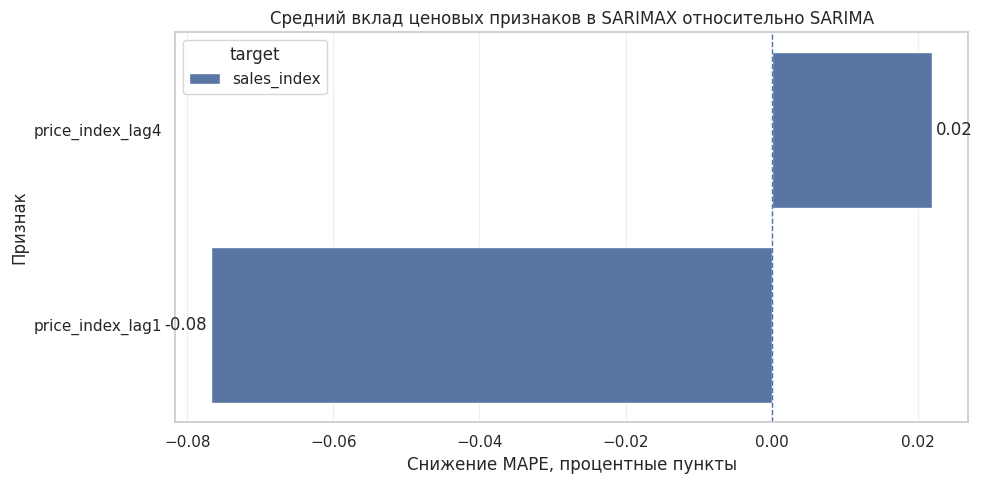

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

if len(price_feature_summary) > 0:
    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data=price_feature_summary,
        x="mean_feature_gain_pp",
        y="exog_feature",
        hue="target"
    )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title("Средний вклад ценовых признаков в SARIMAX относительно SARIMA")
    plt.xlabel("Снижение MAPE, процентные пункты")
    plt.ylabel("Признак")
    plt.grid(axis="x", alpha=0.3)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

    plt.tight_layout()
    plt.show()
else:
    print("Нет SARIMAX-моделей для оценки вклада ценовых признаков")

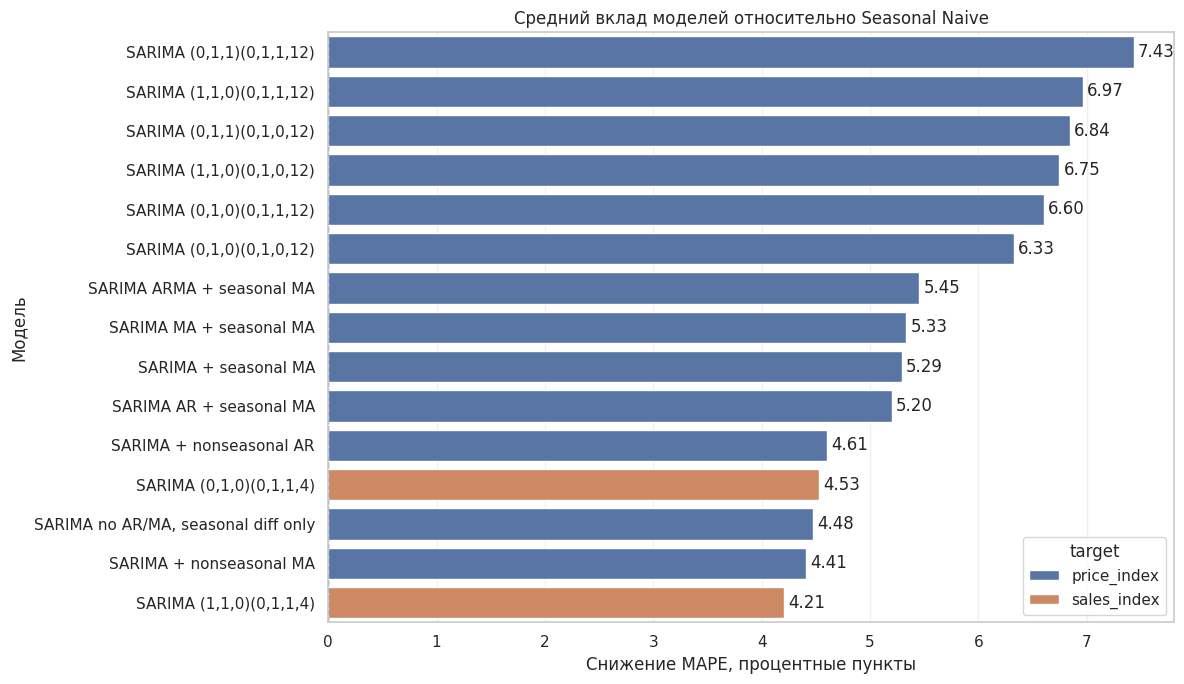

In [79]:
top_model_contribution = (
    model_contribution_summary
    .sort_values("mean_mape_gain_pp", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_model_contribution,
    x="mean_mape_gain_pp",
    y="model",
    hue="target"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Средний вклад моделей относительно Seasonal Naive")
plt.xlabel("Снижение MAPE, процентные пункты")
plt.ylabel("Модель")
plt.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [80]:
all_metrics.to_csv(
    FEATURE_OUT_DIR / "all_loaded_model_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

model_contribution.to_csv(
    FEATURE_OUT_DIR / "model_contribution_vs_seasonal_naive.csv",
    index=False,
    encoding="utf-8-sig"
)

model_contribution_summary.to_csv(
    FEATURE_OUT_DIR / "model_contribution_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

price_feature_contribution.to_csv(
    FEATURE_OUT_DIR / "price_feature_contribution_sarimax_vs_sarima.csv",
    index=False,
    encoding="utf-8-sig"
)

price_feature_summary.to_csv(
    FEATURE_OUT_DIR / "price_feature_contribution_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

sarima_component_contribution.to_csv(
    FEATURE_OUT_DIR / "sarima_component_contribution.csv",
    index=False,
    encoding="utf-8-sig"
)

sarima_component_summary.to_csv(
    FEATURE_OUT_DIR / "sarima_component_contribution_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

overall_contribution_summary.to_csv(
    FEATURE_OUT_DIR / "overall_contribution_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены в:", FEATURE_OUT_DIR)

Файлы сохранены в: /content/gdrive/MyDrive/rostat/feature_contribution
